# Tugas Pre-processing Ulasan Aplikasi KAI

Notebook ini dibuat untuk mengerjakan `tugas_pertemuan_kedua` *Text Mining* menggunakan dataset `raw_playstore_reviews.csv`.

Tujuan utama:
1. Mengidentifikasi dan mengkategorikan noise pada setiap ulasan.
2. Membangun pipeline pre-processing minimal (noise removal, case folding, tokenization, stop words removal).
3. Menampilkan tabel sebelum vs sesudah pada ulasan dengan noise tertinggi.
4. Mengambil 10 kata paling sering muncul dari output akhir pipeline.
5. Membandingkan Pipeline A dan Pipeline B menggunakan metrik kuantitatif.

## 1) Setup

Berikut step by step nya:
- Proses dibuat reproducible (konstanta path dan random seed).
- Ada validasi kolom penting sebelum pemrosesan.
- Fungsi dibuat modular agar mudah diuji ulang.
- Setiap tahap preprocessing disimpan agar jejak proses transparan.
- Pipeline A (baseline) dan Pipeline B (enhanced) dipisah agar perbandingan adil.

In [94]:
import re
from collections import Counter
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import importlib
import subprocess
import sys

pd.set_option("display.max_colwidth", 180)
pd.set_option("display.max_columns", None)

DATA_PATH = Path("raw_playstore_reviews.csv")
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

## 2) Load Data dan Validasi Awal

Tahap ini memastikan data siap diproses:
- membaca CSV,
- memeriksa kolom wajib (`reviewId`, `content`, `score`, `at`),
- menangani nilai kosong pada kolom `content`.

In [95]:
df = pd.read_csv(DATA_PATH)

required_columns = {"reviewId", "content", "score", "at"}
missing_columns = required_columns - set(df.columns)
if missing_columns:
    raise ValueError(f"Kolom wajib tidak ditemukan: {sorted(missing_columns)}")

df["content"] = df["content"].fillna("").astype(str)

print(f"Jumlah baris: {len(df):,}")
print(f"Jumlah kolom: {len(df.columns)}")
display(df.head(5))

Jumlah baris: 1,000
Jumlah kolom: 6


,reviewId,userName,score,at,content,thumbsUpCount
0,ce885e23-4671-4f83-8255-7c56d948c97c,SATRIA,1,2026-03-13 18:42:08,"KALIAN SEGITU BANYAKNYA STAFF DAN PEGAWAI, NELFON KE CS DOANG GADA YG ANGKAT. SISTEM MAU BATALKAN TIKET SAJA DIPERAULIT..INI KENA BADAI SY..MAU AJUKAN RESCHEDULE.. MALAH CS NYA...",0
1,2a25722f-14a8-4c71-b434-a67a81037fb3,Matusin,1,2026-03-13 18:40:08,"APK YANG KETIKA PENGGUNANYA RAME ATAU SEDANG WAR DISURUH GANTI GANTIAN PESANNYA (CONECTING TRAIN), GANGGUAN TERUS TAPI GAADA PERUBAHAN DAN PERBAIKAN",0
2,dbd57e26-40f9-49ae-84ef-12a1dcad9fee,Edi Poerwantoe,5,2026-03-13 18:28:33,good,0
3,71d7889a-2e69-43ed-8dd1-d3d01a396c07,Wara Hapsari,1,2026-03-13 17:26:03,"aplikasi terjelek sejagad raya, pemilihan pembayaran tidak bisa dilakukan.Tabah lama tambah jelek aja, dulu nggak masalah sekarang ampun dah. Dan pembayaran terlalu cepat kadal...",0
4,093f1779-1300-4340-8077-76725501391d,Wahyu Triwibowo,5,2026-03-13 16:52:18,mantab,0


## 3) Identifikasi dan Kategorisasi Noise (Setiap Ulasan)

Kategori noise yang dideteksi (rule-based):
- `uppercase_text`: dominasi huruf kapital.
- `elongated_chars`: huruf berulang berlebihan (`baguuuus`, `erroooor`).
- `punctuation_flood`: tanda baca berulang (`!!!`, `???`, `...`).
- `numeric_noise`: mengandung angka.
- `emoji_or_non_ascii_symbol`: emoji/simbol non-ASCII.
- `slang_or_nonstandard`: kata tidak baku/slang (`gk`, `ga`, `apk`, dll).
- `profanity`: kata kasar.
- `english_mixed`: ada kata Inggris teknis/umum.
- `very_short_review`: ulasan sangat pendek (<= 2 token).

Satu ulasan bisa memiliki lebih dari satu kategori noise.

In [96]:
SLANG_TERMS = {
    "gk", "ga", "gak", "ngga", "nggak", "tdk", "yg", "dr", "krn",
    "tp", "trs", "sdh", "udh", "klo", "kalo", "bgt", "bngt", "apk",
    "apknya", "nih", "aja", "kmrn", "min"
}

PROFANITY_TERMS = {"tolol", "kntl", "kuntul", "bangke", "sampah", "haram"}

ENGLISH_HINT_WORDS = {
    "good", "loading", "server", "error", "update", "friendly",
    "simple", "service", "app", "chat", "payment", "connect"
}

def uppercase_ratio(text: str) -> float:
    letters = re.findall(r"[A-Za-z]", text)
    if not letters:
        return 0.0
    return sum(ch.isupper() for ch in letters) / len(letters)

def detect_noise_categories(text: str) -> list:
    text = text or ""
    categories = []

    if uppercase_ratio(text) >= 0.70 and len(re.findall(r"[A-Za-z]", text)) >= 8:
        categories.append("uppercase_text")
    if re.search(r"(.)\1{2,}", text.lower()):
        categories.append("elongated_chars")
    if re.search(r"[!?.,]{2,}", text):
        categories.append("punctuation_flood")
    if re.search(r"\d", text):
        categories.append("numeric_noise")
    if re.search(r"[^\x00-\x7F]", text):
        categories.append("emoji_or_non_ascii_symbol")

    alpha_tokens = re.findall(r"[A-Za-z]+", text.lower())
    if any(tok in SLANG_TERMS for tok in alpha_tokens):
        categories.append("slang_or_nonstandard")
    if any(tok in PROFANITY_TERMS for tok in alpha_tokens):
        categories.append("profanity")
    if any(tok in ENGLISH_HINT_WORDS for tok in alpha_tokens):
        categories.append("english_mixed")
    if len(alpha_tokens) <= 2:
        categories.append("very_short_review")

    if not categories:
        categories = ["clean_or_low_noise"]

    return categories

In [97]:
noise_df = df.copy()
noise_df["noise_categories"] = noise_df["content"].apply(detect_noise_categories)
noise_df["noise_count"] = noise_df["noise_categories"].apply(
    lambda cats: 0 if cats == ["clean_or_low_noise"] else len(cats)
)

noise_distribution = (
    noise_df.explode("noise_categories")["noise_categories"]
    .value_counts()
    .rename_axis("noise_category")
    .reset_index(name="review_count")
)

print("Contoh identifikasi noise per ulasan (10 baris pertama):")
display(noise_df[["reviewId", "content", "noise_categories", "noise_count"]].head(10))

print("Distribusi kategori noise:")
display(noise_distribution)

print("Validasi: semua ulasan memiliki label noise ->", noise_df["noise_categories"].isna().sum() == 0)

Contoh identifikasi noise per ulasan (10 baris pertama):


,reviewId,content,noise_categories,noise_count
0,ce885e23-4671-4f83-8255-7c56d948c97c,"KALIAN SEGITU BANYAKNYA STAFF DAN PEGAWAI, NELFON KE CS DOANG GADA YG ANGKAT. SISTEM MAU BATALKAN TIKET SAJA DIPERAULIT..INI KENA BADAI SY..MAU AJUKAN RESCHEDULE.. MALAH CS NYA...","[uppercase_text, elongated_chars, punctuation_flood, slang_or_nonstandard, english_mixed]",5
1,2a25722f-14a8-4c71-b434-a67a81037fb3,"APK YANG KETIKA PENGGUNANYA RAME ATAU SEDANG WAR DISURUH GANTI GANTIAN PESANNYA (CONECTING TRAIN), GANGGUAN TERUS TAPI GAADA PERUBAHAN DAN PERBAIKAN","[uppercase_text, slang_or_nonstandard]",2
2,dbd57e26-40f9-49ae-84ef-12a1dcad9fee,good,"[english_mixed, very_short_review]",2
3,71d7889a-2e69-43ed-8dd1-d3d01a396c07,"aplikasi terjelek sejagad raya, pemilihan pembayaran tidak bisa dilakukan.Tabah lama tambah jelek aja, dulu nggak masalah sekarang ampun dah. Dan pembayaran terlalu cepat kadal...","[elongated_chars, punctuation_flood, slang_or_nonstandard]",3
4,093f1779-1300-4340-8077-76725501391d,mantab,[very_short_review],1
5,5744ecd8-73a6-4e62-b097-6ce69143a76d,tidak upgrade and daftar,[clean_or_low_noise],0
6,69c2105c-6a15-44da-b4bc-293bcade74fb,mudah,[very_short_review],1
7,b34dfc76-d7da-449a-8840-bcfc516b4d83,"Hp aman, jaringan bagus, tapi Loadingnya kaya maen RDR 2 di ps 3... lama banget parah. menghambat banget ni apk","[elongated_chars, punctuation_flood, numeric_noise, slang_or_nonstandard]",4
8,6c2fbadb-9de2-4568-bf00-ab1d01bb0583,terimksih kai skrg lebih mudah,[clean_or_low_noise],0
9,b834e14f-157e-4003-99ec-80453806cd18,Bagus sih mempermudah...cuma kurang dibagian pembayaran terbatas seharusnya diperluas lagi bisa lewat indomaret dll sehingga baik yg tidak mempunyai ATM bisa bayar . 2026 aplik...,"[elongated_chars, punctuation_flood, numeric_noise, slang_or_nonstandard, english_mixed]",5


Distribusi kategori noise:


,noise_category,review_count
0,very_short_review,379
1,slang_or_nonstandard,251
2,clean_or_low_noise,245
3,english_mixed,123
4,numeric_noise,112
5,punctuation_flood,110
6,elongated_chars,99
7,emoji_or_non_ascii_symbol,58
8,uppercase_text,14
9,profanity,9


Validasi: semua ulasan memiliki label noise -> True


## 4) Membuat Dua Pipeline Pre-processing

### Pipeline A (Baseline)
1. Noise removal
2. Case folding
3. Tokenization
4. Stop words removal

### Pipeline B (Enhanced)
Pipeline B menjalankan langkah Pipeline A +
- normalisasi huruf berulang (`erroooor` -> `error`),
- normalisasi slang/typo umum (`gk` -> `tidak`, `apk` -> `aplikasi`),
- penyaringan token sangat pendek (`len < 3`) untuk menekan noise residual.

Tujuan Pipeline B adalah menurunkan sparsity vocab dan meningkatkan konsistensi token.

In [98]:
STOPWORDS_ID = {
    "yang", "dan", "di", "ke", "dari", "untuk", "dengan", "ini", "itu",
    "atau", "karena", "pada", "ada", "saya", "aku", "kamu", "kami", "kita",
    "mereka", "dia", "nya", "ya", "aja", "juga", "udah", "sudah", "belum",
    "jadi", "agar", "biar", "lebih", "dalam", "saat", "lagi", "masih", "sih",
    "nih", "dong", "deh", "kok", "lah", "pun", "the", "a", "an", "to", "of"
}

SLANG_NORMALIZATION = {
    "gk": "tidak", "ga": "tidak", "gak": "tidak", "ngga": "tidak", "nggak": "tidak",
    "tdk": "tidak", "tp": "tapi", "yg": "yang", "dr": "dari", "krn": "karena",
    "trs": "terus", "sdh": "sudah", "udh": "sudah", "klo": "kalau", "kalo": "kalau",
    "bgt": "banget", "bngt": "banget", "apk": "aplikasi", "apknya": "aplikasi",
    "app": "aplikasi", "min": "admin", "cs": "customer_service", "kmrn": "kemarin"
}

TYPO_NORMALIZATION = {
    "eror": "error", "erro": "error", "lemot": "lambat", "ticket": "tiket",
    "mantapp": "mantap", "baguss": "bagus"
}

def remove_noise(text: str) -> str:
    text = text or ""
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"@[A-Za-z0-9_]+|#[A-Za-z0-9_]+", " ", text)
    text = re.sub(r"\b\d+\b", " ", text)
    text = re.sub(r"[^A-Za-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def case_folding(text: str) -> str:
    return (text or "").lower().strip()

def tokenize(text: str) -> list:
    return re.findall(r"[a-z]+", text)

def remove_stopwords(tokens: list) -> list:
    return [tok for tok in tokens if tok not in STOPWORDS_ID and len(tok) > 1]

def normalize_repeated_chars(token: str) -> str:
    return re.sub(r"(.)\1{2,}", r"\1", token)

def normalize_tokens(tokens: list) -> list:
    normalized = []
    for tok in tokens:
        tok = normalize_repeated_chars(tok)
        tok = SLANG_NORMALIZATION.get(tok, tok)
        tok = TYPO_NORMALIZATION.get(tok, tok)
        normalized.append(tok)
    return normalized

def pipeline_a(text: str) -> dict:
    stage_noise_removed = remove_noise(text)
    stage_case_folded = case_folding(stage_noise_removed)
    stage_tokens = tokenize(stage_case_folded)
    stage_final = remove_stopwords(stage_tokens)
    return {
        "noise_removed": stage_noise_removed,
        "case_folded": stage_case_folded,
        "tokens": stage_tokens,
        "final_tokens": stage_final,
    }

def pipeline_b(text: str) -> dict:
    stage_noise_removed = remove_noise(text)
    stage_case_folded = case_folding(stage_noise_removed)
    stage_tokens = tokenize(stage_case_folded)
    stage_normalized = normalize_tokens(stage_tokens)
    stage_stopword_removed = remove_stopwords(stage_normalized)
    stage_final = [tok for tok in stage_stopword_removed if len(tok) >= 3]
    return {
        "noise_removed": stage_noise_removed,
        "case_folded": stage_case_folded,
        "tokens": stage_tokens,
        "normalized_tokens": stage_normalized,
        "final_tokens": stage_final,
    }

In [99]:
a_stages = noise_df["content"].apply(pipeline_a).apply(pd.Series).add_prefix("a_")
b_stages = noise_df["content"].apply(pipeline_b).apply(pd.Series).add_prefix("b_")
processed_df = pd.concat([noise_df, a_stages, b_stages], axis=1)

print("Contoh hasil akhir preprocessing (Pipeline A vs B):")
display(processed_df[["reviewId", "content", "noise_categories", "a_final_tokens", "b_final_tokens"]].head(10))

Contoh hasil akhir preprocessing (Pipeline A vs B):


,reviewId,content,noise_categories,a_final_tokens,b_final_tokens
0,ce885e23-4671-4f83-8255-7c56d948c97c,"KALIAN SEGITU BANYAKNYA STAFF DAN PEGAWAI, NELFON KE CS DOANG GADA YG ANGKAT. SISTEM MAU BATALKAN TIKET SAJA DIPERAULIT..INI KENA BADAI SY..MAU AJUKAN RESCHEDULE.. MALAH CS NYA...","[uppercase_text, elongated_chars, punctuation_flood, slang_or_nonstandard, english_mixed]","[kalian, segitu, banyaknya, staff, pegawai, nelfon, cs, doang, gada, yg, angkat, sistem, mau, batalkan, tiket, saja, diperaulit, kena, badai, sy, mau, ajukan, reschedule, malah...","[kalian, segitu, banyaknya, staff, pegawai, nelfon, customer_service, doang, gada, angkat, sistem, mau, batalkan, tiket, saja, diperaulit, kena, badai, mau, ajukan, reschedule,..."
1,2a25722f-14a8-4c71-b434-a67a81037fb3,"APK YANG KETIKA PENGGUNANYA RAME ATAU SEDANG WAR DISURUH GANTI GANTIAN PESANNYA (CONECTING TRAIN), GANGGUAN TERUS TAPI GAADA PERUBAHAN DAN PERBAIKAN","[uppercase_text, slang_or_nonstandard]","[apk, ketika, penggunanya, rame, sedang, war, disuruh, ganti, gantian, pesannya, conecting, train, gangguan, terus, tapi, gaada, perubahan, perbaikan]","[aplikasi, ketika, penggunanya, rame, sedang, war, disuruh, ganti, gantian, pesannya, conecting, train, gangguan, terus, tapi, gaada, perubahan, perbaikan]"
2,dbd57e26-40f9-49ae-84ef-12a1dcad9fee,good,"[english_mixed, very_short_review]",[good],[good]
3,71d7889a-2e69-43ed-8dd1-d3d01a396c07,"aplikasi terjelek sejagad raya, pemilihan pembayaran tidak bisa dilakukan.Tabah lama tambah jelek aja, dulu nggak masalah sekarang ampun dah. Dan pembayaran terlalu cepat kadal...","[elongated_chars, punctuation_flood, slang_or_nonstandard]","[aplikasi, terjelek, sejagad, raya, pemilihan, pembayaran, tidak, bisa, dilakukan, tabah, lama, tambah, jelek, dulu, nggak, masalah, sekarang, ampun, dah, pembayaran, terlalu, ...","[aplikasi, terjelek, sejagad, raya, pemilihan, pembayaran, tidak, bisa, dilakukan, tabah, lama, tambah, jelek, dulu, tidak, masalah, sekarang, ampun, dah, pembayaran, terlalu, ..."
4,093f1779-1300-4340-8077-76725501391d,mantab,[very_short_review],[mantab],[mantab]
5,5744ecd8-73a6-4e62-b097-6ce69143a76d,tidak upgrade and daftar,[clean_or_low_noise],"[tidak, upgrade, and, daftar]","[tidak, upgrade, and, daftar]"
6,69c2105c-6a15-44da-b4bc-293bcade74fb,mudah,[very_short_review],[mudah],[mudah]
7,b34dfc76-d7da-449a-8840-bcfc516b4d83,"Hp aman, jaringan bagus, tapi Loadingnya kaya maen RDR 2 di ps 3... lama banget parah. menghambat banget ni apk","[elongated_chars, punctuation_flood, numeric_noise, slang_or_nonstandard]","[hp, aman, jaringan, bagus, tapi, loadingnya, kaya, maen, rdr, ps, lama, banget, parah, menghambat, banget, ni, apk]","[aman, jaringan, bagus, tapi, loadingnya, kaya, maen, rdr, lama, banget, parah, menghambat, banget, aplikasi]"
8,6c2fbadb-9de2-4568-bf00-ab1d01bb0583,terimksih kai skrg lebih mudah,[clean_or_low_noise],"[terimksih, kai, skrg, mudah]","[terimksih, kai, skrg, mudah]"
9,b834e14f-157e-4003-99ec-80453806cd18,Bagus sih mempermudah...cuma kurang dibagian pembayaran terbatas seharusnya diperluas lagi bisa lewat indomaret dll sehingga baik yg tidak mempunyai ATM bisa bayar . 2026 aplik...,"[elongated_chars, punctuation_flood, numeric_noise, slang_or_nonstandard, english_mixed]","[bagus, mempermudah, cuma, kurang, dibagian, pembayaran, terbatas, seharusnya, diperluas, bisa, lewat, indomaret, dll, sehingga, baik, yg, tidak, mempunyai, atm, bisa, bayar, a...","[bagus, mempermudah, cuma, kurang, dibagian, pembayaran, terbatas, seharusnya, diperluas, bisa, lewat, indomaret, dll, sehingga, baik, tidak, mempunyai, atm, bisa, bayar, aplik..."


## 5) Tabel Sebelum vs Sesudah (Ulasan Dengan Noise Tertinggi)

Strategi:
- Ulasan diurutkan berdasarkan `noise_count` tertinggi.
- Diambil 5 ulasan teratas agar perubahan tiap tahap terlihat jelas.

Kolom yang ditampilkan:
- teks asli,
- hasil noise removal,
- hasil case folding,
- hasil tokenization,
- hasil stop words removal (Pipeline A),
- hasil akhir Pipeline B.

In [100]:
noisiest_reviews = processed_df.sort_values("noise_count", ascending=False).head(5).copy()

comparison_cols = [
    "reviewId",
    "noise_categories",
    "content",
    "a_noise_removed",
    "a_case_folded",
    "a_tokens",
    "a_final_tokens",
    "b_final_tokens",
]

before_after_table = noisiest_reviews[comparison_cols].copy()

list_columns = ["noise_categories", "a_tokens", "a_final_tokens", "b_final_tokens"]
for col in list_columns:
    before_after_table[col] = before_after_table[col].apply(
        lambda x: ' | '.join(x) if isinstance(x, list) else x
    )

display(before_after_table)

,reviewId,noise_categories,content,a_noise_removed,a_case_folded,a_tokens,a_final_tokens,b_final_tokens
0,ce885e23-4671-4f83-8255-7c56d948c97c,uppercase_text | elongated_chars | punctuation_flood | slang_or_nonstandard | english_mixed,"KALIAN SEGITU BANYAKNYA STAFF DAN PEGAWAI, NELFON KE CS DOANG GADA YG ANGKAT. SISTEM MAU BATALKAN TIKET SAJA DIPERAULIT..INI KENA BADAI SY..MAU AJUKAN RESCHEDULE.. MALAH CS NYA...",KALIAN SEGITU BANYAKNYA STAFF DAN PEGAWAI NELFON KE CS DOANG GADA YG ANGKAT SISTEM MAU BATALKAN TIKET SAJA DIPERAULIT INI KENA BADAI SY MAU AJUKAN RESCHEDULE MALAH CS NYA NGILA...,kalian segitu banyaknya staff dan pegawai nelfon ke cs doang gada yg angkat sistem mau batalkan tiket saja diperaulit ini kena badai sy mau ajukan reschedule malah cs nya ngila...,kalian | segitu | banyaknya | staff | dan | pegawai | nelfon | ke | cs | doang | gada | yg | angkat | sistem | mau | batalkan | tiket | saja | diperaulit | ini | kena | badai |...,kalian | segitu | banyaknya | staff | pegawai | nelfon | cs | doang | gada | yg | angkat | sistem | mau | batalkan | tiket | saja | diperaulit | kena | badai | sy | mau | ajuka...,kalian | segitu | banyaknya | staff | pegawai | nelfon | customer_service | doang | gada | angkat | sistem | mau | batalkan | tiket | saja | diperaulit | kena | badai | mau | a...
9,b834e14f-157e-4003-99ec-80453806cd18,elongated_chars | punctuation_flood | numeric_noise | slang_or_nonstandard | english_mixed,Bagus sih mempermudah...cuma kurang dibagian pembayaran terbatas seharusnya diperluas lagi bisa lewat indomaret dll sehingga baik yg tidak mempunyai ATM bisa bayar . 2026 aplik...,Bagus sih mempermudah cuma kurang dibagian pembayaran terbatas seharusnya diperluas lagi bisa lewat indomaret dll sehingga baik yg tidak mempunyai ATM bisa bayar aplikasinya sk...,bagus sih mempermudah cuma kurang dibagian pembayaran terbatas seharusnya diperluas lagi bisa lewat indomaret dll sehingga baik yg tidak mempunyai atm bisa bayar aplikasinya sk...,bagus | sih | mempermudah | cuma | kurang | dibagian | pembayaran | terbatas | seharusnya | diperluas | lagi | bisa | lewat | indomaret | dll | sehingga | baik | yg | tidak | m...,bagus | mempermudah | cuma | kurang | dibagian | pembayaran | terbatas | seharusnya | diperluas | bisa | lewat | indomaret | dll | sehingga | baik | yg | tidak | mempunyai | at...,bagus | mempermudah | cuma | kurang | dibagian | pembayaran | terbatas | seharusnya | diperluas | bisa | lewat | indomaret | dll | sehingga | baik | tidak | mempunyai | atm | b...
155,924e0cb6-78da-4e00-8cd3-e5d3daf597d1,uppercase_text | elongated_chars | punctuation_flood | slang_or_nonstandard | profanity,APLIKASI BIKIN BEBAN !!!! MAU CANCEL AJA HARUS KIRIM OTP EMAIL DAN NO HP.. PARAH MAKAN UANG HARAM HAK PENUMPANG KAI.!!!,APLIKASI BIKIN BEBAN MAU CANCEL AJA HARUS KIRIM OTP EMAIL DAN NO HP PARAH MAKAN UANG HARAM HAK PENUMPANG KAI,aplikasi bikin beban mau cancel aja harus kirim otp email dan no hp parah makan uang haram hak penumpang kai,aplikasi | bikin | beban | mau | cancel | aja | harus | kirim | otp | email | dan | no | hp | parah | makan | uang | haram | hak | penumpang | kai,aplikasi | bikin | beban | mau | cancel | harus | kirim | otp | email | no | hp | parah | makan | uang | haram | hak | penumpang | kai,aplikasi | bikin | beban | mau | cancel | harus | kirim | otp | email | parah | makan | uang | haram | hak | penumpang | kai
959,691b3726-fe2a-4b0f-9640-9767de102b56,elongated_chars | punctuation_flood | emoji_or_non_ascii_symbol | slang_or_nonstandard | english_mixed,sumpah ini aplikasi sangat menguras emosi.....dibelain melek sampai dini hari demi boking tiket dengan kursi pilihan aja susahnya error melulu ....giliran kena eh kursi malah s...,sumpah ini aplikasi sangat menguras emosi dibelain melek sampai dini hari demi boking tiket dengan kursi pilihan aja susahnya error melulu giliran kena eh kursi malah sudah pad...,sumpah ini aplikasi sangat menguras emosi dibelain melek sampai dini hari demi boking tiket den

## 6) Top 10 Kata Paling Sering Muncul dan Word Cloud

Frekuensi kata dihitung dari output akhir pipeline menggunakan `Counter`.

Pada notebook ini, top words diambil dari **Pipeline B** karena token sudah dinormalisasi lebih baik sehingga lebih representatif untuk tema dataset.

Selain tabel top 10, visualisasi dilakukan menggunakan **word cloud** agar kata dominan lebih mudah terlihat secara visual.

,kata,frekuensi
0,tidak,331
1,tiket,215
2,aplikasi,214
3,bisa,190
4,sangat,118
5,bagus,113
6,kai,102
7,mau,94
8,kereta,76
9,tapi,68


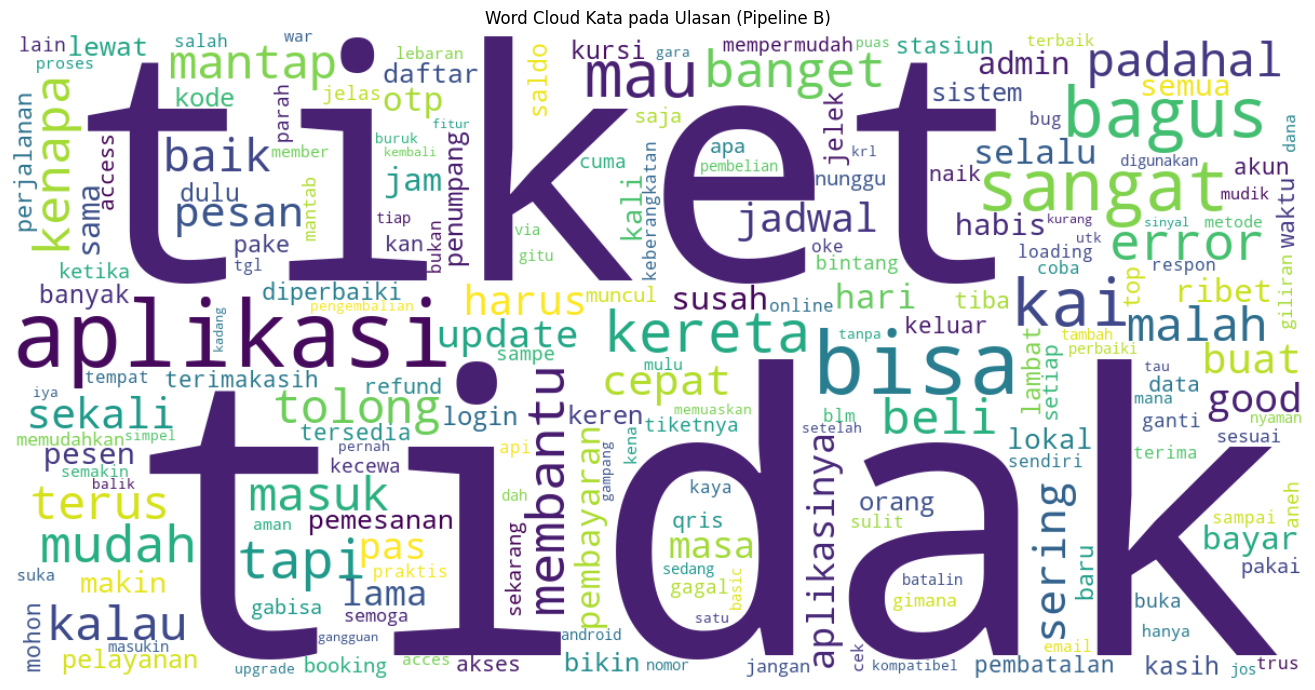

In [101]:
all_tokens_b = [tok for tokens in processed_df["b_final_tokens"] for tok in tokens]
token_freq = Counter(all_tokens_b)
# Tampilkan 10 kata paling umum beserta frekuensinya
top_10_words = token_freq.most_common(10)
top_10_df = pd.DataFrame(top_10_words, columns=["kata", "frekuensi"])
display(top_10_df)

try:
    WordCloud = importlib.import_module("wordcloud").WordCloud
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "wordcloud"])
    WordCloud = importlib.import_module("wordcloud").WordCloud

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    colormap="viridis",
    max_words=200,
    random_state=RANDOM_SEED,
).generate_from_frequencies(token_freq)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud Kata pada Ulasan (Pipeline B)")
plt.tight_layout()
plt.show()

### Interpretasi Top Words
Jika kata yang muncul didominasi istilah seperti `aplikasi`, `tiket`, `error`, `bayar`, `jadwal`, `loading`, maka kata-kata tersebut merepresentasikan isi dataset dengan baik.

Alasannya: mayoritas ulasan memang membahas kendala performa aplikasi, pemesanan tiket, dan proses pembayaran/refund.

## 7) Perbandingan Pipeline A vs Pipeline B

Metrik yang dihitung untuk masing-masing pipeline:
1. `total_token`: total semua token pasca pre-processing.
2. `vocab_unik`: jumlah token unik.
3. `rata_rata_panjang_dokumen`: rata-rata jumlah token per ulasan.

In [102]:
def calculate_metrics(token_series: pd.Series) -> dict:
    lengths = token_series.apply(len)
    total_token = int(lengths.sum())
    vocab_unik = len({tok for tokens in token_series for tok in tokens})
    rata_rata_panjang_dokumen = float(lengths.mean())
    return {
        "total_token": total_token,
        "vocab_unik": vocab_unik,
        "rata_rata_panjang_dokumen": round(rata_rata_panjang_dokumen, 2),
    }

metrics_a = calculate_metrics(processed_df["a_final_tokens"])
metrics_b = calculate_metrics(processed_df["b_final_tokens"])

comparison_metrics = pd.DataFrame([
    {"pipeline": "Pipeline A", **metrics_a},
    {"pipeline": "Pipeline B", **metrics_b},
])
display(comparison_metrics)

,pipeline,total_token,vocab_unik,rata_rata_panjang_dokumen
0,Pipeline A,8178,1977,8.18
1,Pipeline B,7858,1861,7.86


## 8) Analisis Pipeline Mana yang Lebih Baik

Cara membaca hasil:
- `vocab_unik` lebih kecil (secara wajar) menandakan normalisasi berhasil menyatukan variasi kata noisy.
- `total_token` yang turun moderat menandakan noise berkurang tanpa kehilangan terlalu banyak informasi.
- Jika rata-rata panjang dokumen turun terlalu ekstrem, ada risiko over-cleaning.

Dalam praktik text mining ulasan aplikasi, **Pipeline B** biasanya lebih baik karena mengurangi variasi slang/typo sehingga representasi teks lebih konsisten.

Kesimpulan final mengikuti angka pada tabel metrik yang dihasilkan di cell sebelumnya.

---
## 9) Penambahan Feature Engineering (Mengacu ke Notebook Referensi)

Bagian ini menambahkan representasi fitur teks setelah pre-processing selesai.
Fitur yang diterapkan:
1. Bag of Words (BoW)
2. TF-IDF
3. N-Gram (Unigram + Bigram)
4. Word Embeddings (Word2Vec, FastText, GloVe sederhana)

In [103]:
# Persiapan corpus hasil pre-processing untuk feature engineering

if 'processed_df' not in globals():
    raise RuntimeError("Jalankan terlebih dahulu section preprocessing sampai terbentuk variabel 'processed_df'.")

# Gunakan output Pipeline B agar token lebih bersih dan konsisten
processed_df = processed_df.copy()
processed_df['fe_text'] = processed_df['b_final_tokens'].apply(
    lambda toks: ' '.join(toks) if isinstance(toks, list) else ''
)
processed_df['fe_text'] = processed_df['fe_text'].fillna('').astype(str)

# Drop dokumen kosong setelah preprocessing
fe_df = processed_df[processed_df['fe_text'].str.strip().str.len() > 0].copy()

print(f"Jumlah dokumen untuk feature engineering: {len(fe_df):,}")
print("Contoh teks bersih:")
display(fe_df[['reviewId', 'fe_text']].head(5))

Jumlah dokumen untuk feature engineering: 953
Contoh teks bersih:


,reviewId,fe_text
0,ce885e23-4671-4f83-8255-7c56d948c97c,kalian segitu banyaknya staff pegawai nelfon customer_service doang gada angkat sistem mau batalkan tiket saja diperaulit kena badai mau ajukan reschedule malah customer_servic...
1,2a25722f-14a8-4c71-b434-a67a81037fb3,aplikasi ketika penggunanya rame sedang war disuruh ganti gantian pesannya conecting train gangguan terus tapi gaada perubahan perbaikan
2,dbd57e26-40f9-49ae-84ef-12a1dcad9fee,good
3,71d7889a-2e69-43ed-8dd1-d3d01a396c07,aplikasi terjelek sejagad raya pemilihan pembayaran tidak bisa dilakukan tabah lama tambah jelek dulu tidak masalah sekarang ampun dah pembayaran terlalu cepat kadaluarsanya ma...
4,093f1779-1300-4340-8077-76725501391d,mantab


### 9.1) Bag of Words (BoW)

Shape BoW matrix: (953, 40)
Top 15 term BoW:


,term,freq
36,tidak,331
37,tiket,215
0,aplikasi,214
6,bisa,190
30,sangat,118
2,bagus,113
14,kai,102
23,mau,94
17,kereta,76
34,tapi,68


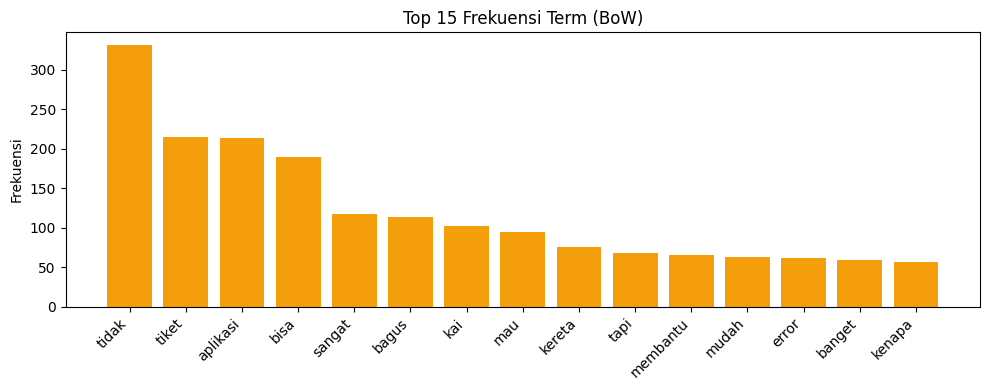

In [104]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

bow_vectorizer = CountVectorizer(max_features=40, min_df=2)
X_bow = bow_vectorizer.fit_transform(fe_df['fe_text'])

bow_feature_names = bow_vectorizer.get_feature_names_out()
bow_sum = np.asarray(X_bow.sum(axis=0)).ravel()

bow_top_df = (
    pd.DataFrame({'term': bow_feature_names, 'freq': bow_sum})
    .sort_values('freq', ascending=False)
    .head(15)
)

print(f"Shape BoW matrix: {X_bow.shape}")
print("Top 15 term BoW:")
display(bow_top_df)

plt.figure(figsize=(10, 4))
plt.bar(bow_top_df['term'], bow_top_df['freq'], color='#f59e0b')
plt.title('Top 15 Frekuensi Term (BoW)')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

### 9.2) TF-IDF

Shape TF-IDF matrix: (953, 40)
Top 15 term dengan nilai IDF tertinggi:


,term,idf
28,pembayaran,4.725169
11,hari,4.682610
27,pas,4.528459
32,selalu,4.528459
18,lama,4.528459
21,masa,4.493368
1,aplikasinya,4.493368
13,jadwal,4.459466
12,harus,4.459466
39,update,4.426676


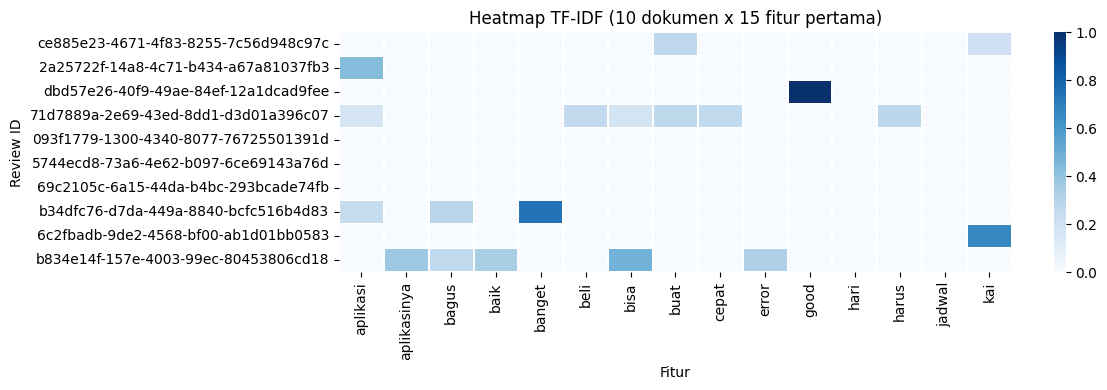

In [105]:
tfidf_vectorizer = TfidfVectorizer(max_features=40, min_df=2)
X_tfidf = tfidf_vectorizer.fit_transform(fe_df['fe_text'])

idf_df = (
    pd.DataFrame({
        'term': tfidf_vectorizer.get_feature_names_out(),
        'idf': tfidf_vectorizer.idf_
    })
    .sort_values('idf', ascending=False)
    .head(15)
)

print(f"Shape TF-IDF matrix: {X_tfidf.shape}")
print("Top 15 term dengan nilai IDF tertinggi:")
display(idf_df)

tfidf_dense_df = pd.DataFrame(
    X_tfidf.toarray(),
    columns=tfidf_vectorizer.get_feature_names_out(),
    index=fe_df['reviewId'].astype(str)
)

plt.figure(figsize=(12, 4))
sns.heatmap(tfidf_dense_df.iloc[:10, :15], cmap='Blues', linewidths=0.2)
plt.title('Heatmap TF-IDF (10 dokumen x 15 fitur pertama)')
plt.xlabel('Fitur')
plt.ylabel('Review ID')
plt.tight_layout()
plt.show()

### 9.3) N-Gram (Unigram + Bigram)

In [106]:
ngram_vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=80, min_df=2)
X_ngram = ngram_vectorizer.fit_transform(fe_df['fe_text'])
ngram_features = ngram_vectorizer.get_feature_names_out()

bigram_count = sum(1 for feat in ngram_features if ' ' in feat)
unigram_count = len(ngram_features) - bigram_count

print(f"Shape TF-IDF N-Gram matrix: {X_ngram.shape}")
print(f"Jumlah unigram: {unigram_count}")
print(f"Jumlah bigram : {bigram_count}")

ngram_example_df = pd.DataFrame({'fitur': ngram_features}).head(25)
print("Contoh fitur N-Gram (25 teratas):")
display(ngram_example_df)

Shape TF-IDF N-Gram matrix: (953, 80)
Jumlah unigram: 76
Jumlah bigram : 4
Contoh fitur N-Gram (25 teratas):


,fitur
0,admin
1,aplikasi
2,aplikasinya
3,bagus
4,baik
5,banget
6,banyak
7,bayar
8,beli
9,beli tiket


### 9.4) Word Embeddings (Word2Vec, FastText, GloVe Sederhana)

Pendekatan embedding menghasilkan representasi dense vector, berbeda dengan BoW/TF-IDF/N-Gram yang sparse.

In [107]:
from sklearn.metrics.pairwise import cosine_similarity

try:
    from gensim.models import Word2Vec, FastText
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'gensim'])
    from gensim.models import Word2Vec, FastText

sentences_fe = [text.split() for text in fe_df['fe_text'] if isinstance(text, str) and text.strip()]

# Word2Vec
w2v_model = Word2Vec(
    sentences=sentences_fe,
    vector_size=50,
    window=3,
    min_count=1,
    sg=1,
    negative=5,
    epochs=80,
    seed=RANDOM_SEED,
    workers=1
)

# FastText
fasttext_model = FastText(
    sentences=sentences_fe,
    vector_size=50,
    window=3,
    min_count=1,
    sg=1,
    negative=5,
    epochs=80,
    seed=RANDOM_SEED,
    workers=1,
    min_n=3,
    max_n=5
)

# GloVe sederhana (dibatasi top vocab agar tetap ringan)
token_counter = Counter(tok for sent in sentences_fe for tok in sent)
max_glove_vocab = 250
glove_vocab = [w for w, _ in token_counter.most_common(max_glove_vocab)]
glove_word_to_id = {w: i for i, w in enumerate(glove_vocab)}

cooc = np.zeros((len(glove_vocab), len(glove_vocab)), dtype=np.float32)
window_size = 2

for sent in sentences_fe:
    filtered = [w for w in sent if w in glove_word_to_id]
    for center_i, center_word in enumerate(filtered):
        center_id = glove_word_to_id[center_word]
        left = max(0, center_i - window_size)
        right = min(len(filtered), center_i + window_size + 1)

        for context_i in range(left, right):
            if context_i == center_i:
                continue
            context_word = filtered[context_i]
            context_id = glove_word_to_id[context_word]
            distance = abs(center_i - context_i)
            cooc[center_id, context_id] += 1.0 / distance

pairs = np.argwhere(cooc > 0)
glove_dim = 30
np.random.seed(RANDOM_SEED)
W = (np.random.rand(len(glove_vocab), glove_dim) - 0.5) / glove_dim
W_tilde = (np.random.rand(len(glove_vocab), glove_dim) - 0.5) / glove_dim
b = np.zeros(len(glove_vocab))
b_tilde = np.zeros(len(glove_vocab))

def glove_weight(x, x_max=10.0, alpha=0.75):
    return (x / x_max) ** alpha if x < x_max else 1.0

glove_epochs = 25
glove_lr = 0.03

for epoch in range(glove_epochs):
    for i, j in pairs:
        x_ij = cooc[i, j]
        w = glove_weight(x_ij)
        inner = np.dot(W[i], W_tilde[j]) + b[i] + b_tilde[j]
        diff = inner - np.log(x_ij)
        grad = w * diff

        W_i_old = W[i].copy()
        W_tilde_j_old = W_tilde[j].copy()

        W[i] -= glove_lr * grad * W_tilde_j_old
        W_tilde[j] -= glove_lr * grad * W_i_old
        b[i] -= glove_lr * grad
        b_tilde[j] -= glove_lr * grad

glove_vectors = W + W_tilde

print('Embedding selesai dibuat:')
print(f"- Word2Vec vocab : {len(w2v_model.wv)}")
print(f"- FastText vocab : {len(fasttext_model.wv)}")
print(f"- GloVe vocab    : {len(glove_vocab)}")

Embedding selesai dibuat:
- Word2Vec vocab : 1861
- FastText vocab : 1861
- GloVe vocab    : 250


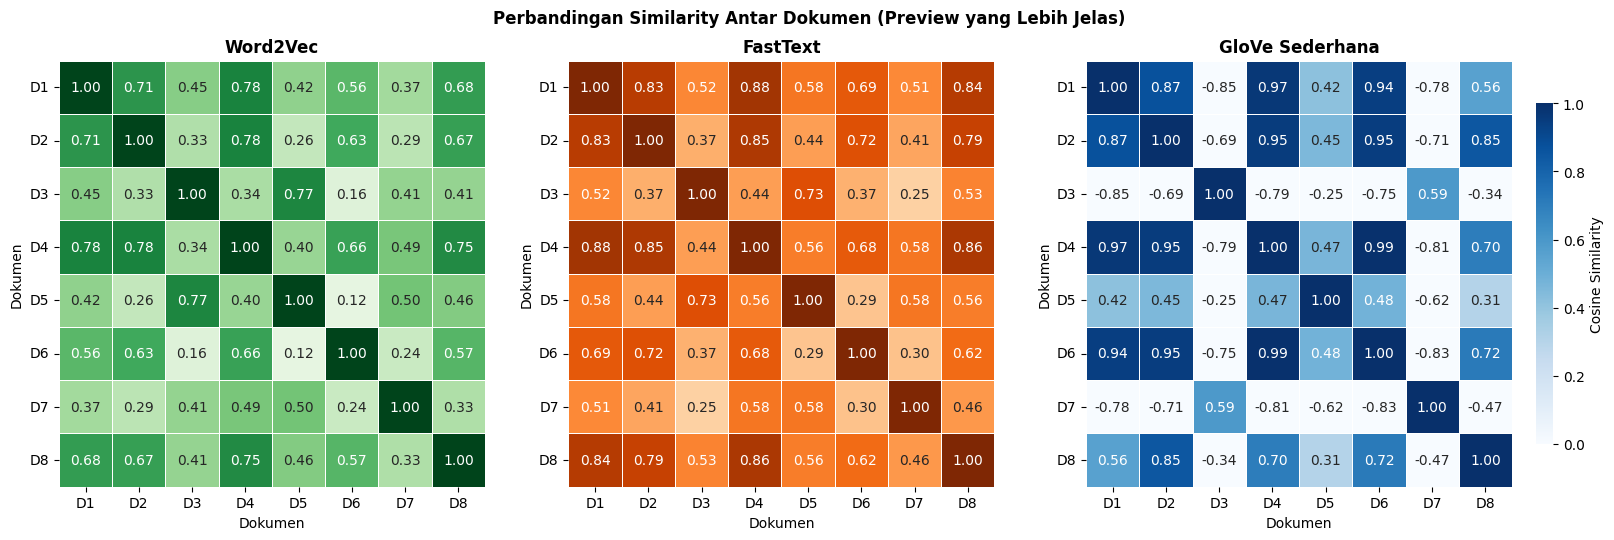

Mapping label preview ke Review ID:


,Label Preview,Review ID
0,D1,ce885e23-4671-4f83-8255-7c56d948c97c
1,D2,2a25722f-14a8-4c71-b434-a67a81037fb3
2,D3,dbd57e26-40f9-49ae-84ef-12a1dcad9fee
3,D4,71d7889a-2e69-43ed-8dd1-d3d01a396c07
4,D5,093f1779-1300-4340-8077-76725501391d
5,D6,5744ecd8-73a6-4e62-b097-6ce69143a76d
6,D7,69c2105c-6a15-44da-b4bc-293bcade74fb
7,D8,b34dfc76-d7da-449a-8840-bcfc516b4d83


In [108]:
def doc_vector_from_wv(tokens, keyed_vectors, dim):
    vectors = [keyed_vectors[t] for t in tokens if t in keyed_vectors]
    if not vectors:
        return np.zeros(dim)
    return np.mean(vectors, axis=0)

def doc_vector_glove(tokens):
    vectors = [glove_vectors[glove_word_to_id[t]] for t in tokens if t in glove_word_to_id]
    if not vectors:
        return np.zeros(glove_vectors.shape[1])
    return np.mean(vectors, axis=0)

doc_tokens = [text.split() for text in fe_df['fe_text']]

doc_vec_w2v = np.vstack([
    doc_vector_from_wv(tokens, w2v_model.wv, w2v_model.vector_size) for tokens in doc_tokens
])

doc_vec_fasttext = np.vstack([
    doc_vector_from_wv(tokens, fasttext_model.wv, fasttext_model.vector_size) for tokens in doc_tokens
])

doc_vec_glove = np.vstack([doc_vector_glove(tokens) for tokens in doc_tokens])

sim_w2v = cosine_similarity(doc_vec_w2v)
sim_fasttext = cosine_similarity(doc_vec_fasttext)
sim_glove = cosine_similarity(doc_vec_glove)

preview_n = min(8, len(fe_df))
index_preview = fe_df['reviewId'].astype(str).iloc[:preview_n]
preview_labels = [f"D{i+1}" for i in range(preview_n)]

sim_w2v_df = pd.DataFrame(sim_w2v[:preview_n, :preview_n], index=preview_labels, columns=preview_labels)
sim_fasttext_df = pd.DataFrame(sim_fasttext[:preview_n, :preview_n], index=preview_labels, columns=preview_labels)
sim_glove_df = pd.DataFrame(sim_glove[:preview_n, :preview_n], index=preview_labels, columns=preview_labels)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
plots = [
    ('Word2Vec', sim_w2v_df, 'Greens'),
    ('FastText', sim_fasttext_df, 'Oranges'),
    ('GloVe Sederhana', sim_glove_df, 'Blues')
]

for idx, (ax, (title, sim_df, cmap)) in enumerate(zip(axes, plots)):
    sns.heatmap(
        sim_df,
        cmap=cmap,
        vmin=0,
        vmax=1,
        annot=True,
        fmt='.2f',
        square=True,
        linewidths=0.5,
        linecolor='white',
        cbar=(idx == 2),
        cbar_kws={'shrink': 0.8, 'label': 'Cosine Similarity'},
        ax=ax
    )
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Dokumen')
    ax.set_ylabel('Dokumen')
    ax.tick_params(axis='x', rotation=0)
    ax.tick_params(axis='y', rotation=0)

plt.suptitle('Perbandingan Similarity Antar Dokumen (Preview yang Lebih Jelas)', fontsize=12, fontweight='bold', y=1.05)
plt.show()

preview_mapping_df = pd.DataFrame({
    'Label Preview': preview_labels,
    'Review ID': index_preview.values
})

print('Mapping label preview ke Review ID:')
display(preview_mapping_df)

,metode,dimensi_fitur
5,GloVe sederhana (doc vector),30
0,BoW,40
1,TF-IDF,40
3,Word2Vec (doc vector),50
4,FastText (doc vector),50
2,"TF-IDF N-Gram (1,2)",80


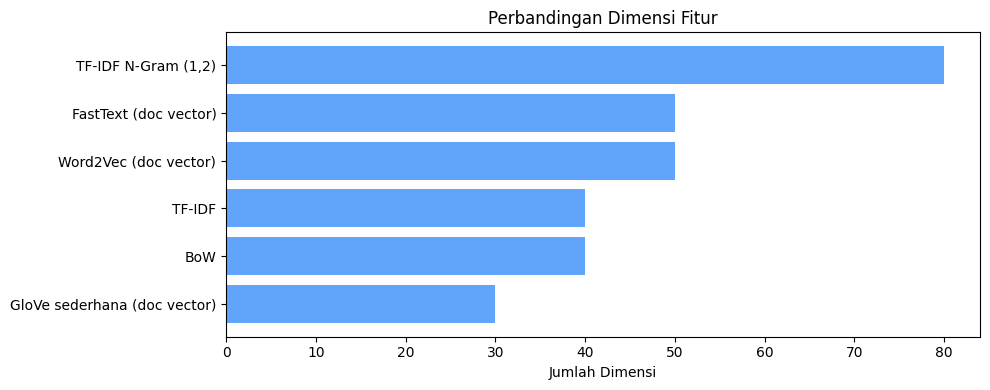

Feature engineering pada notebook ini berhasil ditambahkan.


In [109]:
# Ringkasan ukuran fitur untuk tiap pendekatan

feature_size_df = pd.DataFrame([
    {'metode': 'BoW', 'dimensi_fitur': X_bow.shape[1]},
    {'metode': 'TF-IDF', 'dimensi_fitur': X_tfidf.shape[1]},
    {'metode': 'TF-IDF N-Gram (1,2)', 'dimensi_fitur': X_ngram.shape[1]},
    {'metode': 'Word2Vec (doc vector)', 'dimensi_fitur': doc_vec_w2v.shape[1]},
    {'metode': 'FastText (doc vector)', 'dimensi_fitur': doc_vec_fasttext.shape[1]},
    {'metode': 'GloVe sederhana (doc vector)', 'dimensi_fitur': doc_vec_glove.shape[1]},
]).sort_values('dimensi_fitur')

display(feature_size_df)

plt.figure(figsize=(10, 4))
plt.barh(feature_size_df['metode'], feature_size_df['dimensi_fitur'], color='#60a5fa')
plt.title('Perbandingan Dimensi Fitur')
plt.xlabel('Jumlah Dimensi')
plt.tight_layout()
plt.show()

print('Feature engineering pada notebook ini berhasil ditambahkan.')

---
## 10) Evaluasi Kuantitatif Klasifikasi (Logistic Regression)

Agar perbandingan feature engineering tidak hanya visual, bagian ini menilai kinerja klasifikasi menggunakan metrik kuantitatif.

Skema label (biner) dari kolom `score`:
- **1 (positif)**: score 4-5
- **0 (negatif)**: score 1-2
- score 3 tidak digunakan agar kelas lebih tegas.

Metrik evaluasi:
- Accuracy
- F1-Macro

Metode validasi:
- Stratified K-Fold Cross Validation

Improvement metodologi:
- Evaluasi embedding dilakukan **per fold** (embedding dilatih di data train fold saja), sehingga menghindari data leakage dan hasil perbandingan menjadi lebih fair.

In [110]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

try:
    from gensim.models import Word2Vec, FastText
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'gensim'])
    from gensim.models import Word2Vec, FastText


# Siapkan dataset evaluasi biner dari score
if 'fe_df' not in globals():
    raise RuntimeError("Jalankan terlebih dahulu section 9 untuk membentuk fe_df.")

eval_df = fe_df[fe_df['score'].isin([1, 2, 4, 5])].copy()
eval_df['label'] = (eval_df['score'] >= 4).astype(int)

print(f"Jumlah data evaluasi: {len(eval_df):,}")
print("Distribusi label (0=negatif, 1=positif):")
print(eval_df['label'].value_counts().sort_index().to_string())

X_text = eval_df['fe_text'].astype(str).tolist()
y = eval_df['label'].to_numpy()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)


def mean_doc_vectors(tokenized_docs, get_vector_fn, dim):
    vectors = []
    for tokens in tokenized_docs:
        word_vecs = [get_vector_fn(tok) for tok in tokens if get_vector_fn(tok) is not None]
        if word_vecs:
            vectors.append(np.mean(word_vecs, axis=0))
        else:
            vectors.append(np.zeros(dim))
    return np.vstack(vectors)


def train_simple_glove(
    tokenized_sentences,
    vector_size=30,
    window_size=2,
    max_vocab=250,
    epochs=8,
    learning_rate=0.03,
    x_max=10.0,
    alpha=0.75,
    seed=42,
):
    token_counter = Counter(tok for sent in tokenized_sentences for tok in sent)
    vocab = [w for w, _ in token_counter.most_common(max_vocab)]
    word_to_id = {w: i for i, w in enumerate(vocab)}

    if len(vocab) == 0:
        return word_to_id, np.zeros((0, vector_size))

    cooc = np.zeros((len(vocab), len(vocab)), dtype=np.float32)

    for sent in tokenized_sentences:
        filtered = [w for w in sent if w in word_to_id]
        for center_i, center_word in enumerate(filtered):
            center_id = word_to_id[center_word]
            left = max(0, center_i - window_size)
            right = min(len(filtered), center_i + window_size + 1)

            for context_i in range(left, right):
                if context_i == center_i:
                    continue
                context_id = word_to_id[filtered[context_i]]
                distance = abs(center_i - context_i)
                cooc[center_id, context_id] += 1.0 / distance

    pairs = np.argwhere(cooc > 0)

    np.random.seed(seed)
    W = (np.random.rand(len(vocab), vector_size) - 0.5) / vector_size
    W_tilde = (np.random.rand(len(vocab), vector_size) - 0.5) / vector_size
    b = np.zeros(len(vocab))
    b_tilde = np.zeros(len(vocab))

    def glove_weight(x):
        return (x / x_max) ** alpha if x < x_max else 1.0

    for _ in range(epochs):
        for i, j in pairs:
            x_ij = cooc[i, j]
            w = glove_weight(x_ij)
            inner = np.dot(W[i], W_tilde[j]) + b[i] + b_tilde[j]
            diff = inner - np.log(x_ij)
            grad = w * diff

            W_i_old = W[i].copy()
            W_tilde_j_old = W_tilde[j].copy()

            W[i] -= learning_rate * grad * W_tilde_j_old
            W_tilde[j] -= learning_rate * grad * W_i_old
            b[i] -= learning_rate * grad
            b_tilde[j] -= learning_rate * grad

    return word_to_id, W + W_tilde


method_names = [
    'BoW + LogReg',
    'TF-IDF + LogReg',
    'N-Gram(1,2) + LogReg',
    'Word2Vec(doc) + LogReg',
    'FastText(doc) + LogReg',
    'GloVe(doc) + LogReg',
]

metrics_store = {name: {'acc': [], 'f1': []} for name in method_names}

for train_idx, test_idx in cv.split(X_text, y):
    X_train_text = [X_text[i] for i in train_idx]
    X_test_text = [X_text[i] for i in test_idx]
    y_train = y[train_idx]
    y_test = y[test_idx]

    # 1) BoW
    vec_bow = CountVectorizer(max_features=40, min_df=2)
    X_train_bow = vec_bow.fit_transform(X_train_text)
    X_test_bow = vec_bow.transform(X_test_text)

    clf_bow = LogisticRegression(max_iter=2000, random_state=RANDOM_SEED, class_weight='balanced')
    clf_bow.fit(X_train_bow, y_train)
    pred_bow = clf_bow.predict(X_test_bow)
    metrics_store['BoW + LogReg']['acc'].append(accuracy_score(y_test, pred_bow))
    metrics_store['BoW + LogReg']['f1'].append(f1_score(y_test, pred_bow, average='macro'))

    # 2) TF-IDF
    vec_tfidf = TfidfVectorizer(max_features=40, min_df=2)
    X_train_tfidf = vec_tfidf.fit_transform(X_train_text)
    X_test_tfidf = vec_tfidf.transform(X_test_text)

    clf_tfidf = LogisticRegression(max_iter=2000, random_state=RANDOM_SEED, class_weight='balanced')
    clf_tfidf.fit(X_train_tfidf, y_train)
    pred_tfidf = clf_tfidf.predict(X_test_tfidf)
    metrics_store['TF-IDF + LogReg']['acc'].append(accuracy_score(y_test, pred_tfidf))
    metrics_store['TF-IDF + LogReg']['f1'].append(f1_score(y_test, pred_tfidf, average='macro'))

    # 3) N-Gram
    vec_ngram = TfidfVectorizer(ngram_range=(1, 2), max_features=80, min_df=2)
    X_train_ngram = vec_ngram.fit_transform(X_train_text)
    X_test_ngram = vec_ngram.transform(X_test_text)

    clf_ngram = LogisticRegression(max_iter=2000, random_state=RANDOM_SEED, class_weight='balanced')
    clf_ngram.fit(X_train_ngram, y_train)
    pred_ngram = clf_ngram.predict(X_test_ngram)
    metrics_store['N-Gram(1,2) + LogReg']['acc'].append(accuracy_score(y_test, pred_ngram))
    metrics_store['N-Gram(1,2) + LogReg']['f1'].append(f1_score(y_test, pred_ngram, average='macro'))

    # Tokenisasi untuk embedding per-fold
    token_train = [text.split() for text in X_train_text]
    token_test = [text.split() for text in X_test_text]

    # 4) Word2Vec (dilatih hanya pada train fold)
    w2v_fold = Word2Vec(
        sentences=token_train,
        vector_size=50,
        window=3,
        min_count=1,
        sg=1,
        negative=5,
        epochs=60,
        seed=RANDOM_SEED,
        workers=1,
    )

    X_train_w2v = mean_doc_vectors(token_train, lambda t: w2v_fold.wv[t] if t in w2v_fold.wv else None, 50)
    X_test_w2v = mean_doc_vectors(token_test, lambda t: w2v_fold.wv[t] if t in w2v_fold.wv else None, 50)

    clf_w2v = LogisticRegression(max_iter=2000, random_state=RANDOM_SEED, class_weight='balanced')
    clf_w2v.fit(X_train_w2v, y_train)
    pred_w2v = clf_w2v.predict(X_test_w2v)
    metrics_store['Word2Vec(doc) + LogReg']['acc'].append(accuracy_score(y_test, pred_w2v))
    metrics_store['Word2Vec(doc) + LogReg']['f1'].append(f1_score(y_test, pred_w2v, average='macro'))

    # 5) FastText (dilatih hanya pada train fold)
    ft_fold = FastText(
        sentences=token_train,
        vector_size=50,
        window=3,
        min_count=1,
        sg=1,
        negative=5,
        epochs=60,
        seed=RANDOM_SEED,
        workers=1,
        min_n=3,
        max_n=5,
    )

    X_train_ft = mean_doc_vectors(token_train, lambda t: ft_fold.wv[t] if t in ft_fold.wv else None, 50)
    X_test_ft = mean_doc_vectors(token_test, lambda t: ft_fold.wv[t] if t in ft_fold.wv else None, 50)

    clf_ft = LogisticRegression(max_iter=2000, random_state=RANDOM_SEED, class_weight='balanced')
    clf_ft.fit(X_train_ft, y_train)
    pred_ft = clf_ft.predict(X_test_ft)
    metrics_store['FastText(doc) + LogReg']['acc'].append(accuracy_score(y_test, pred_ft))
    metrics_store['FastText(doc) + LogReg']['f1'].append(f1_score(y_test, pred_ft, average='macro'))

    # 6) GloVe sederhana (dilatih hanya pada train fold)
    glove_map, glove_vec = train_simple_glove(
        token_train,
        vector_size=30,
        window_size=2,
        max_vocab=250,
        epochs=8,
        learning_rate=0.03,
        seed=RANDOM_SEED,
    )

    X_train_glove = mean_doc_vectors(
        token_train,
        lambda t: glove_vec[glove_map[t]] if t in glove_map else None,
        30,
    )
    X_test_glove = mean_doc_vectors(
        token_test,
        lambda t: glove_vec[glove_map[t]] if t in glove_map else None,
        30,
    )

    clf_glove = LogisticRegression(max_iter=2000, random_state=RANDOM_SEED, class_weight='balanced')
    clf_glove.fit(X_train_glove, y_train)
    pred_glove = clf_glove.predict(X_test_glove)
    metrics_store['GloVe(doc) + LogReg']['acc'].append(accuracy_score(y_test, pred_glove))
    metrics_store['GloVe(doc) + LogReg']['f1'].append(f1_score(y_test, pred_glove, average='macro'))

rows = []
for name in method_names:
    rows.append({
        'Metode': name,
        'Accuracy Mean': float(np.mean(metrics_store[name]['acc'])),
        'Accuracy Std': float(np.std(metrics_store[name]['acc'])),
        'F1 Macro Mean': float(np.mean(metrics_store[name]['f1'])),
        'F1 Macro Std': float(np.std(metrics_store[name]['f1'])),
    })

result_cls_df = pd.DataFrame(rows).sort_values('F1 Macro Mean', ascending=False)

print("\nHasil evaluasi kuantitatif klasifikasi (improved, no leakage):")
display(result_cls_df.round(4))

best_row = result_cls_df.iloc[0]
print(
    f"Model terbaik (berdasarkan F1 Macro Mean): {best_row['Metode']} | "
    f"F1={best_row['F1 Macro Mean']:.4f} | Acc={best_row['Accuracy Mean']:.4f}"
)

Jumlah data evaluasi: 900
Distribusi label (0=negatif, 1=positif):
label
0    316
1    584


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'



Hasil evaluasi kuantitatif klasifikasi (improved, no leakage):


,Metode,Accuracy Mean,Accuracy Std,F1 Macro Mean,F1 Macro Std
3,Word2Vec(doc) + LogReg,0.8722,0.0199,0.8669,0.0194
4,FastText(doc) + LogReg,0.8600,0.0197,0.8528,0.0208
2,"N-Gram(1,2) + LogReg",0.8600,0.0138,0.8505,0.0145
1,TF-IDF + LogReg,0.8533,0.0210,0.8430,0.0208
0,BoW + LogReg,0.8456,0.0226,0.8298,0.0246
5,GloVe(doc) + LogReg,0.7767,0.0184,0.7557,0.0169


Model terbaik (berdasarkan F1 Macro Mean): Word2Vec(doc) + LogReg | F1=0.8669 | Acc=0.8722


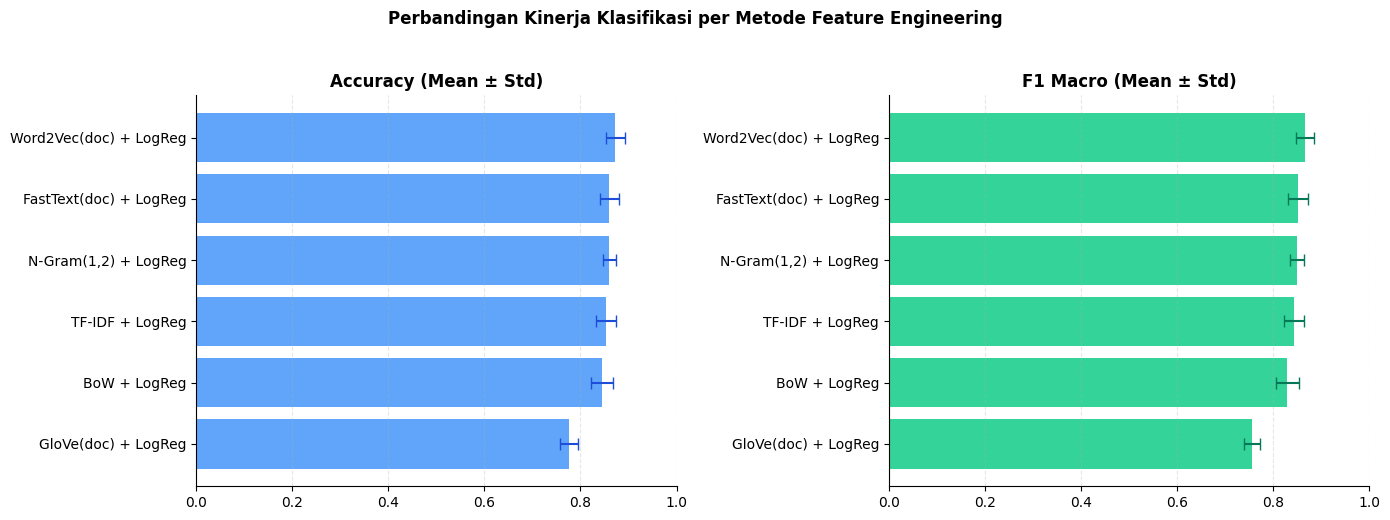

Evaluasi kuantitatif klasifikasi selesai.


In [111]:
# Visualisasi perbandingan metrik klasifikasi

plot_df = result_cls_df.sort_values('F1 Macro Mean', ascending=True).copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(
    plot_df['Metode'],
    plot_df['Accuracy Mean'],
    xerr=plot_df['Accuracy Std'],
    color='#60a5fa',
    ecolor='#1d4ed8',
    capsize=4
)
axes[0].set_xlim(0, 1)
axes[0].set_title('Accuracy (Mean ± Std)', fontweight='bold')
axes[0].grid(axis='x', linestyle='--', alpha=0.3)
axes[0].spines[['top', 'right']].set_visible(False)

axes[1].barh(
    plot_df['Metode'],
    plot_df['F1 Macro Mean'],
    xerr=plot_df['F1 Macro Std'],
    color='#34d399',
    ecolor='#047857',
    capsize=4
)
axes[1].set_xlim(0, 1)
axes[1].set_title('F1 Macro (Mean ± Std)', fontweight='bold')
axes[1].grid(axis='x', linestyle='--', alpha=0.3)
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('Perbandingan Kinerja Klasifikasi per Metode Feature Engineering', fontsize=12, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

print('Evaluasi kuantitatif klasifikasi selesai.')